In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 11.4 MB/s eta 0:00:00

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 50000

SEED = 15
EPOCHS_FINAL = 10
BATCH_SIZE = 16

# Set seed for reproducibility
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print(f"Oversampling Method: SMOTETomek (SMOTE + Tomek Links Cleaning)")
print(f"Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:30%:300%")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 10 (NO Early Stopping)
Oversampling Method: SMOTETomek (SMOTE + Tomek Links Cleaning)
Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:30%:300%


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT
# ============================================================================

def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        # Search for perovskite materials
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        # Get material summaries
        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                   "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            # Collect data
            record = {
                'material_id': str(doc.material_id),
                'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density': float(doc.density) if hasattr(doc, 'density') else None,
                'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                'structure': structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)

# Load data
print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

# Check data types
print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

# Display columns/features
print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

# Display top 4 samples (excluding structure column for readability)
print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density     volume  nsites
0  mp-1183288  BaInO3          cubic  6.331162  78.721649       5
1  mp-1183286  BaDyO3          cubic  6.651911  86.828787       5
2  mp-1183284  BaLiO3          cubic  4.677365  68.257565       5
3  mp-1183282  BaBeO3          cubic  5.464992  59.049462       5


In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

# Visualize missing values only if there are any
if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!



CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


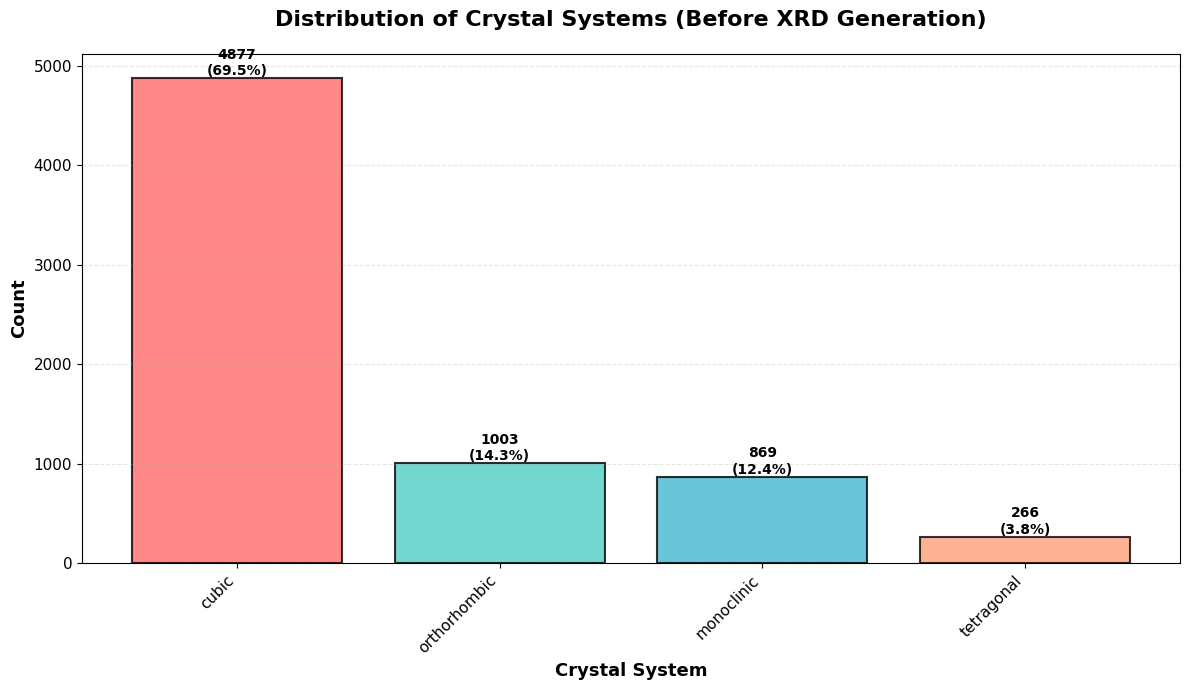

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

# Plot distribution
plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# XRD PATTERN GENERATION
# ============================================================================

def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    material_ids = []  # Store material IDs
    formulas = []  # Store formulas
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            material_ids.append(row['material_id'])
            formulas.append(row['formula'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)
    material_ids = np.array(material_ids)
    formulas = np.array(formulas)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"Crystal system distribution:\n{Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, material_ids, formulas, valid_indices

# Generate XRD patterns
two_theta_grid, X_raw, y_str, material_ids, formulas, valid_idx = generate_xrd_patterns(df_materials)

# Update dataframe to keep only valid materials
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/7015 patterns... (7.1%)
✓ Processed 1000/7015 patterns... (14.3%)
✓ Processed 1500/7015 patterns... (21.4%)
✓ Processed 2000/7015 patterns... (28.5%)
✓ Processed 2500/7015 patterns... (35.6%)
✓ Processed 3000/7015 patterns... (42.8%)
✓ Processed 3500/7015 patterns... (49.9%)
✓ Processed 4000/7015 patterns... (57.0%)
✓ Processed 4500/7015 patterns... (64.1%)
✓ Processed 5000/7015 patterns... (71.3%)
✓ Processed 5500/7015 patterns... (78.4%)
✓ Processed 6000/7015 patterns... (85.5%)
✓ Processed 6500/7015 patterns... (92.7%)
✓ Processed 7000/7015 patterns... (99.8%)

XRD GENERATION SUMMARY
✓ Successfully generated: 7015 patterns
✗ Failed: 0 patterns
Success rate: 100.00%
Pattern shape: (7015, 2048)
Crystal system distribution:
Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples



XRD PATTERN VISUALIZATION (WITH FORMULA)
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 4877 samples available
Plotting Monoclinic: 869 samples available
Plotting Orthorhombic: 1003 samples available
Plotting Tetragonal: 266 samples available


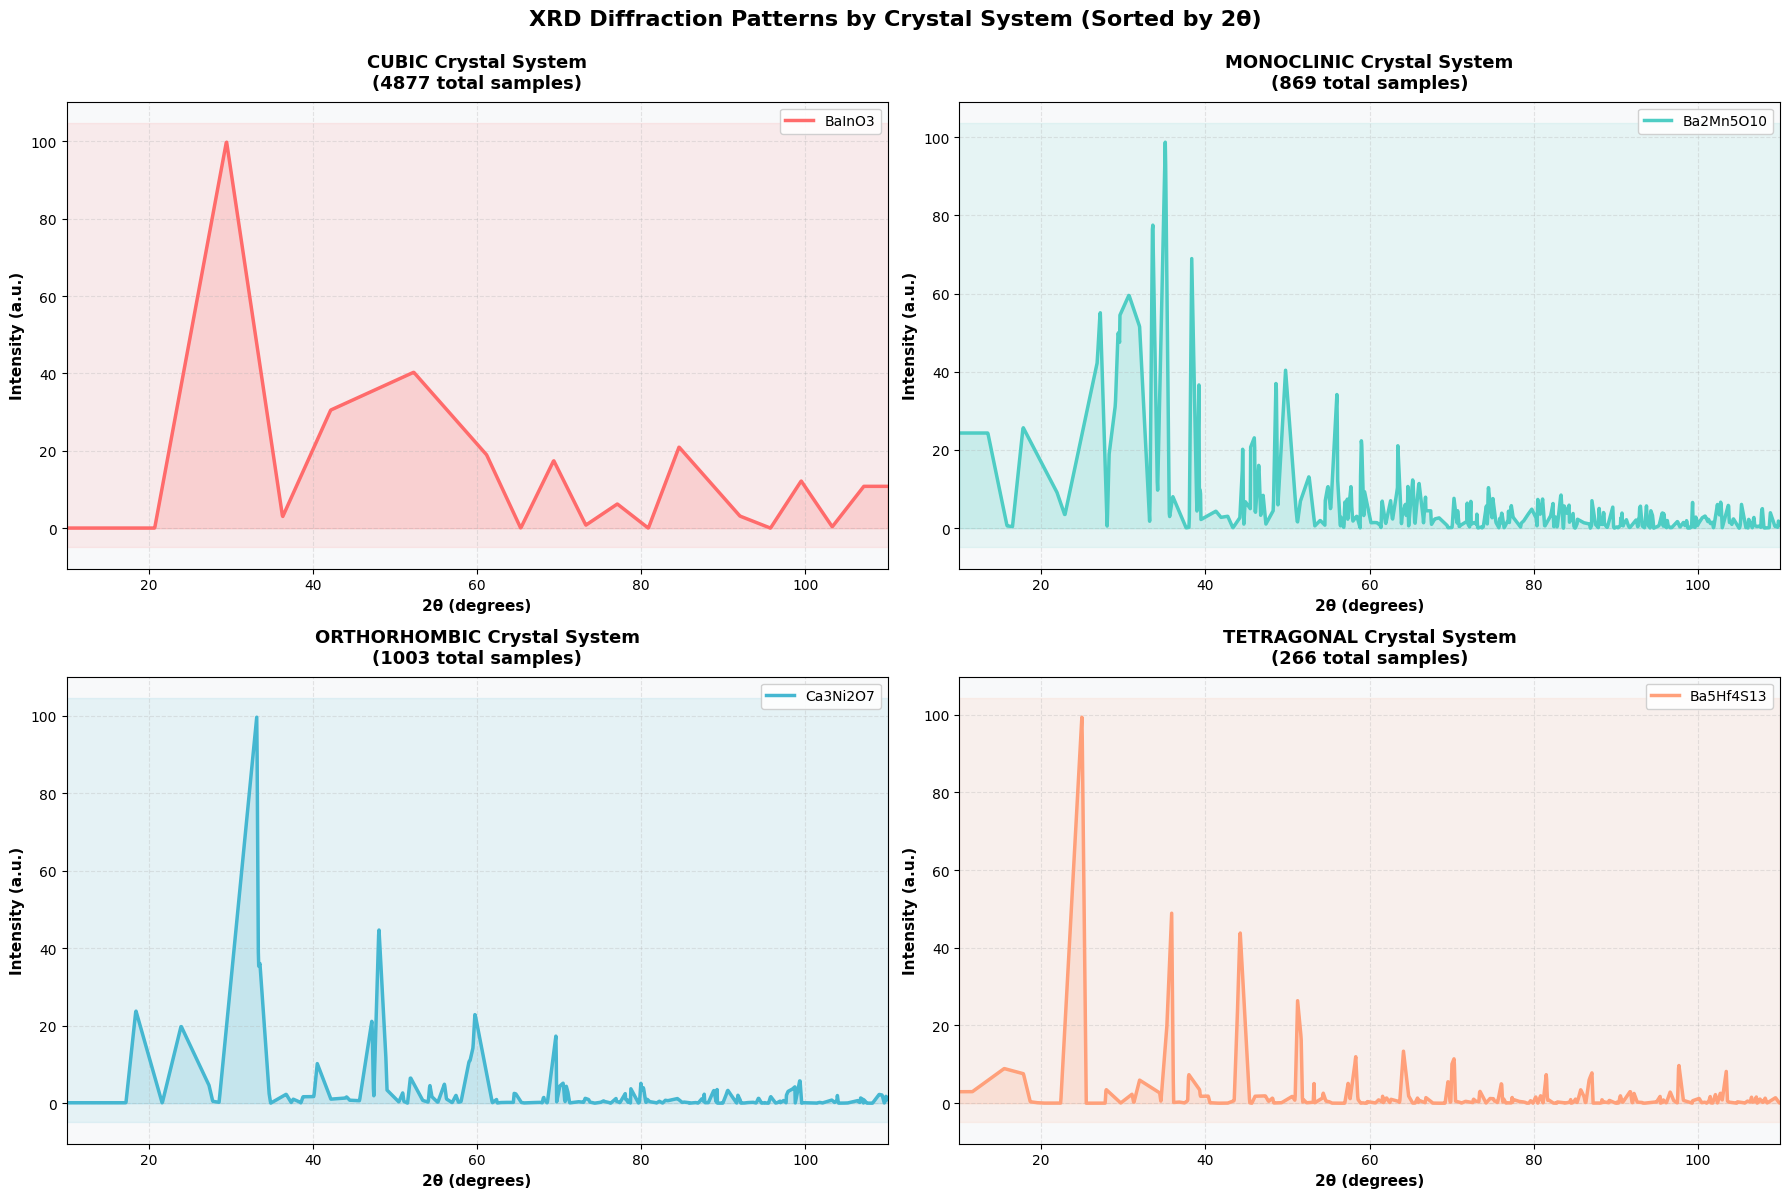


✓ XRD patterns visualization complete!
✓ Each pattern shows chemical formula


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION (WITH FORMULA ONLY)
# ============================================================================

print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION (WITH FORMULA)")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]

    # Get indices for this system
    system_indices = np.where(y_str == system)[0]

    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        # Take only 1 sample (first sample)
        sample_idx = system_indices[0]

        # Get formula
        formula = formulas[sample_idx]

        # Get pattern data
        pattern_data = X_raw[sample_idx]

        # Sort by 2θ (should already be sorted, but ensuring)
        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        # Plot the sorted pattern
        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5,
               color=colors_map[system],
               label=f'{formula}')

        # Fill under the curve for better visualization
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')

    # Add subtle background color
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color=colors_map[system])

    # Set x-axis limits
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (Sorted by 2θ)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ XRD patterns visualization complete!")
print("✓ Each pattern shows chemical formula")

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# Split data: 70% train, 10% validation, 20% test
# First split: 80% (train+val), 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# Second split: 70% train, 10% validation (from the 80%)
# 10/80 = 0.125
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:                 {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:       4910 samples (70.0%)
Validation set size:      702 samples (10.0%)
Test set size:           1403 samples (20.0%)
Total:                   7015 samples

Training Set Distribution:
  Cubic          :  3414 samples ( 69.5%)
  Monoclinic     :   608 samples ( 12.4%)
  Orthorhombic   :   702 samples ( 14.3%)
  Tetragonal     :   186 samples (  3.8%)

Validation Set Distribution:
  Cubic          :   488 samples ( 69.5%)
  Monoclinic     :    87 samples ( 12.4%)
  Orthorhombic   :   100 samples ( 14.2%)
  Tetragonal     :    27 samples (  3.8%)

Test Set Distribution:
 

In [ ]:
# ============================================================================
# APPLYING SMOTETOMEK (STANDARD - AUTO BALANCE ALL CLASSES)
# ============================================================================

print("\n" + "="*70)
print("APPLYING SMOTETomek (STANDARD)")
print("="*70)
print("Strategy:")
print("  • SMOTE     : Oversample semua kelas minoritas hingga seimbang dengan kelas mayoritas")
print("  • Tomek Links: Hapus sampel borderline/overlapping antar kelas untuk mengurangi overlap")
print("  • sampling_strategy='auto' → semua kelas diseimbangkan ke jumlah kelas mayoritas")
print()

print("BEFORE SMOTETomek:")
print("-" * 50)
print(f"Training samples: {len(X_train_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    current_count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {current_count:>5} samples")

# Apply standard SMOTETomek
# - SMOTE (sampling_strategy='auto'): oversample kelas minoritas ke jumlah kelas mayoritas
# - Tomek Links: bersihkan pasangan sampel yang terlalu berdekatan dari kelas berbeda
smotetomek = SMOTETomek(
    random_state=SEED,
    # sampling_strategy default = 'auto' → menyeimbangkan semua kelas ke mayoritas
)

X_train_smote, y_train_smote = smotetomek.fit_resample(X_train_raw, y_train)

print("\n" + "="*70)
print("AFTER SMOTETomek:")
print("-" * 50)
print(f"Training samples: {len(X_train_smote)} (changed by {len(X_train_smote) - len(X_train_raw):+d})")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_smote == i)
    original_count = np.sum(y_train == i)
    diff = count - original_count
    diff_pct = (diff / original_count * 100) if original_count > 0 else 0
    sign = '+' if diff >= 0 else ''
    print(f"  {name.capitalize():<15}: {count:>5} samples (Original: {original_count}, {sign}{diff} = {sign}{diff_pct:.1f}%)")

print("\nNote: Jumlah akhir mungkin sedikit berbeda dari target karena")
print("      Tomek Links menghapus sampel borderline untuk mengurangi class overlap.")

print("\n" + "="*70)
print("VALIDATION SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Validation samples: {len(X_val_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n" + "="*70)
print("TEST SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Test samples: {len(X_test_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n✓ SMOTETomek applied successfully!")
print(f"✓ SMOTE: semua kelas minoritas di-oversample ke jumlah kelas mayoritas (auto)")
print(f"✓ Tomek Links: sampel borderline/overlapping dihapus untuk memperjelas batas kelas")


APPLYING SMOTETomek (STANDARD)
Strategy:
  • SMOTE     : Oversample semua kelas minoritas hingga seimbang dengan kelas mayoritas
  • Tomek Links: Hapus sampel borderline/overlapping antar kelas untuk mengurangi overlap
  • sampling_strategy='auto' → semua kelas diseimbangkan ke jumlah kelas mayoritas

BEFORE SMOTETomek:
--------------------------------------------------
Training samples: 4910

Class distribution:
  Cubic          :  3414 samples
  Monoclinic     :   608 samples
  Orthorhombic   :   702 samples
  Tetragonal     :   186 samples

AFTER SMOTETomek:
--------------------------------------------------
Training samples: 13654 (changed by +8744)

Class distribution:
  Cubic          :  3413 samples (Original: 3414, -1 = -0.0%)
  Monoclinic     :  3414 samples (Original: 608, +2806 = +461.5%)
  Orthorhombic   :  3413 samples (Original: 702, +2711 = +386.2%)
  Tetragonal     :  3414 samples (Original: 186, +3228 = +1735.5%)

Note: Jumlah akhir mungkin sedikit berbeda dari target

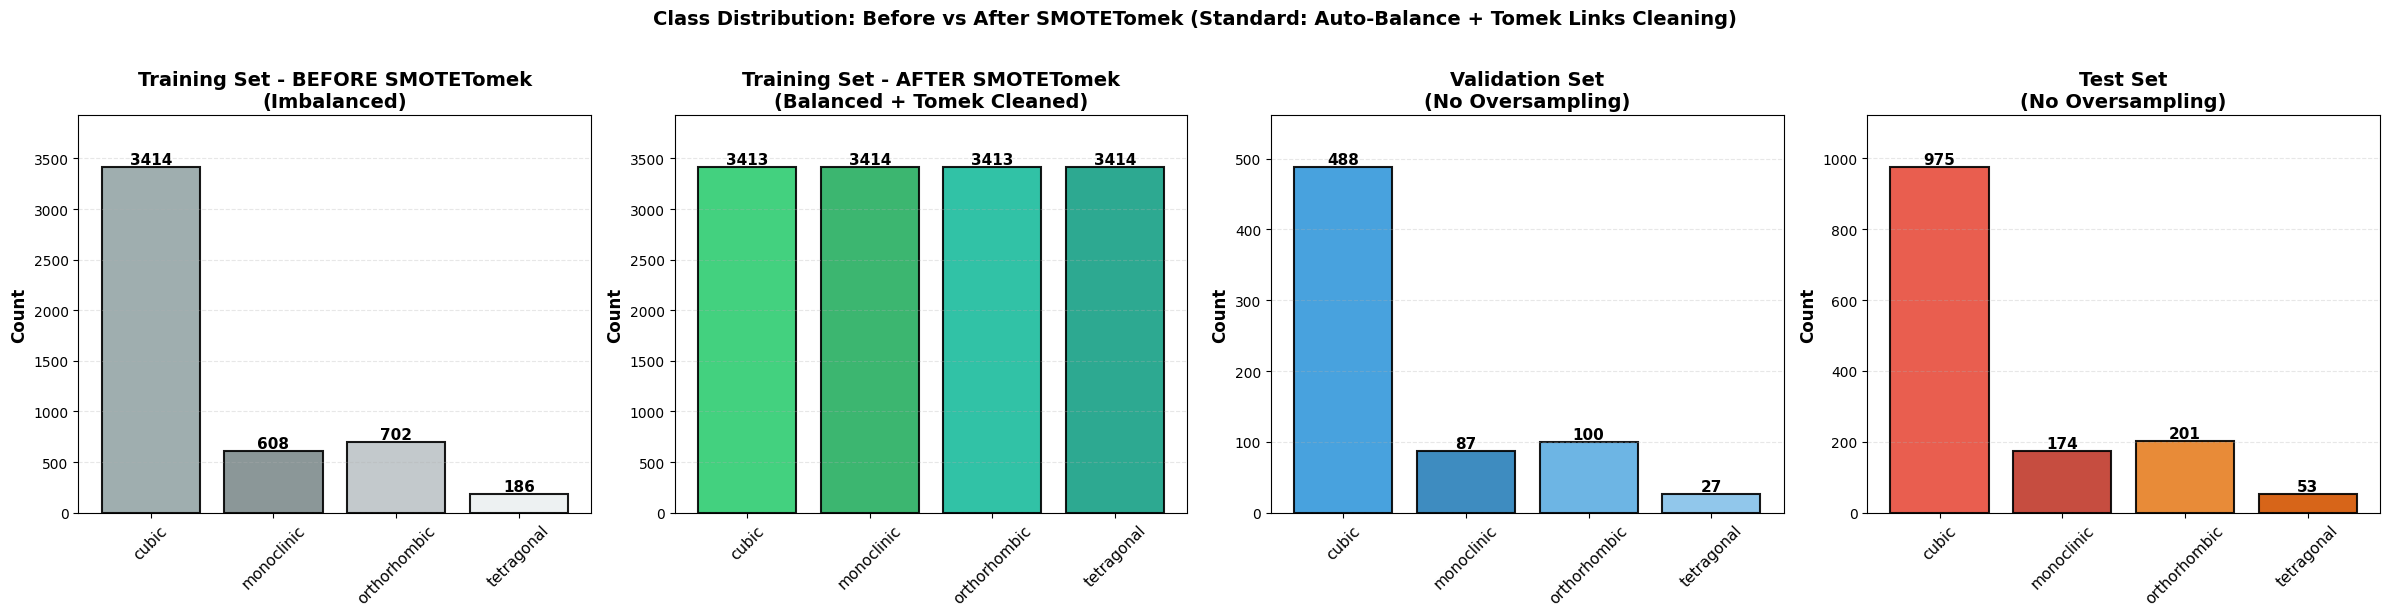

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Color palettes
colors_before = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_after = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_val = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']
colors_test = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

# Plot 1: Training Before SMOTETomek
unique, counts = np.unique(y_train, return_counts=True)
labels = [class_names[i] for i in unique]
bars1 = axes[0].bar(labels, counts, color=colors_before, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[0].set_title('Training Set - BEFORE SMOTETomek\n(Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Training After SMOTETomek
unique, counts = np.unique(y_train_smote, return_counts=True)
labels = [class_names[i] for i in unique]
bars2 = axes[1].bar(labels, counts, color=colors_after, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[1].set_title('Training Set - AFTER SMOTETomek\n(Balanced + Tomek Cleaned)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Validation Set
unique, counts = np.unique(y_val, return_counts=True)
labels = [class_names[i] for i in unique]
bars3 = axes[2].bar(labels, counts, color=colors_val, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[2].set_title('Validation Set\n(No Oversampling)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars3, counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 4: Test Set
unique, counts = np.unique(y_test, return_counts=True)
labels = [class_names[i] for i in unique]
bars4 = axes[3].bar(labels, counts, color=colors_test, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[3].set_title('Test Set\n(No Oversampling)', fontweight='bold', fontsize=14)
axes[3].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[3].tick_params(axis='x', rotation=45, labelsize=11)
axes[3].grid(axis='y', alpha=0.3, linestyle='--')
axes[3].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars4, counts):
    height = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution: Before vs After SMOTETomek (Standard: Auto-Balance + Tomek Links Cleaning)',
            fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    - 3 Conv1D layers: filters=80, kernel_size=[100, 80, 20], stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: 80 filters, kernel_size=100, stride=5
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: 80 filters, kernel_size=80, stride=5
    x = layers.Conv1D(filters=80, kernel_size=40, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: 40 filters, kernel_size=20, stride=5
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)


    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    Architecture:
    - 4 Conv1D layers: all with kernel_size optimized, stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout

    WOA optimizes:
    - Number of filters for all 3 conv layers (same value)
    - Fully connected layer 1 units
    - Fully connected layer 2 units (feature layer)
    """
    num_filters = int(params[0])      # Filters for all 3 conv layers
    fc1_units = int(params[1])        # FC layer 1 units
    fc2_units = int(params[2])        # FC layer 2 units (feature layer)

    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: kernel_size=100, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: kernel_size=80, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=70, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=40, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Convolutional Layer 4: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=10, strides=5,
                      activation="relu", padding="same",
                      name="conv4")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool4")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

# Reshape data for CNN (add channel dimension)
X_train_no_smote = X_train_raw[..., np.newaxis]
X_train_with_smote = X_train_smote[..., np.newaxis]
X_val = X_val_raw[..., np.newaxis]
X_test = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train (no SMOTETomek):   {X_train_no_smote.shape}")
print(f"X_train (with SMOTETomek): {X_train_with_smote.shape}")
print(f"X_val:                     {X_val.shape}")
print(f"X_test:                    {X_test.shape}")
print("\n✓ All data ready for training!")


DATA SHAPES FOR TRAINING
X_train (no SMOTETomek):   (4910, 2048, 1)
X_train (with SMOTETomek): (13654, 2048, 1)
X_val:                     (702, 2048, 1)
X_test:                    (1403, 2048, 1)

✓ All data ready for training!


In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN WITHOUT SMOTETOMEK
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (WITHOUT SMOTETomek)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITHOUT SMOTETomek (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_no_smote = build_cnn_fixed(X_train_no_smote.shape[1:], num_classes=len(class_names))
model_cnn_no_smote.summary()

# Train model WITHOUT early stopping
history_cnn_no_smote = model_cnn_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (No SMOTETomek) training complete!")


TRAINING MODEL 1: CNN (WITHOUT SMOTETomek)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITHOUT SMOTETomek (Imbalanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7329 - loss: 0.6874 - val_accuracy: 0.8846 - val_loss: 0.3217
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8631 - loss: 0.3666 - val_accuracy: 0.9003 - val_loss: 0.2970
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8745 - loss: 0.3258 - val_accuracy: 0.8889 - val_loss: 0.3005
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8888 - loss: 0.2765 - val_accuracy: 0.9017 - val_loss: 0.2786
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8881 - loss: 0.2891 - val_accuracy: 0.8960 - val_loss: 0.2835
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9038 - loss: 0.2447 - val_accuracy: 0.9074 - val_loss: 0.2812
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9262 - loss: 0.2052 - val_accuracy: 0.9202 - val_loss: 0.2378
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9300 - loss: 0.2095 - val_accu

In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN WITH SMOTETOMEK
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN (WITH SMOTETomek)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITH SMOTETomek (Custom Augmentation + Tomek Cleaning)")
print("• SMOTE Augmentation: Ortho(+10%), Mono(+30%), Tetra(+300%), Cubic(+0%)")
print("• Tomek Links: borderline/overlapping samples removed to reduce class overlap")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_with_smote = build_cnn_fixed(X_train_with_smote.shape[1:], num_classes=len(class_names))
model_cnn_with_smote.summary()

# Train model WITHOUT early stopping
history_cnn_with_smote = model_cnn_with_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (With SMOTETomek) training complete!")


TRAINING MODEL 2: CNN (WITH SMOTETomek)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITH SMOTETomek (Custom Augmentation + Tomek Cleaning)
• SMOTE Augmentation: Ortho(+10%), Mono(+30%), Tetra(+300%), Cubic(+0%)
• Tomek Links: borderline/overlapping samples removed to reduce class overlap
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6329 - loss: 0.8610 - val_accuracy: 0.9003 - val_loss: 0.2985
Epoch 2/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8967 - loss: 0.3162 - val_accuracy: 0.9088 - val_loss: 0.3002
Epoch 3/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9463 - loss: 0.1711 - val_accuracy: 0.9231 - val_loss: 0.3747
Epoch 4/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9664 - loss: 0.1252 - val_accuracy: 0.9017 - val_loss: 0.3858
Epoch 5/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9744 - loss: 0.0866 - val_accuracy: 0.9088 - val_loss: 0.6372
Epoch 6/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9761 - loss: 0.0866 - val_accuracy: 0.9231 - val_loss: 0.5266
Epoch 7/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9811 - loss: 0.0658 - val_accuracy: 0.9174 - val_loss: 0.5514
Epoch 8/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9824 - loss: 0.0756 - 

In [ ]:
# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

# Predictions
y_pred_cnn_no_smote = np.argmax(model_cnn_no_smote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_with_smote = np.argmax(model_cnn_with_smote.predict(X_test, verbose=0), axis=1)


# Calculate metrics for all models
models_results = {}

for model_name, y_pred in [
    ("CNN (No SMOTETomek)", y_pred_cnn_no_smote),
    ("CNN (With SMOTETomek)", y_pred_cnn_with_smote)
]:
    models_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall': recall_score(y_test, y_pred, average="macro", zero_division=0),
        'f1': f1_score(y_test, y_pred, average="macro", zero_division=0),
        'predictions': y_pred
    }

# Display results
print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Predictions']
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(comparison_df.to_string())

# Highlight best performers
print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<30} ({best_value:.4f})")


MODEL COMPARISON - TEST SET PERFORMANCE
                       Accuracy Precision    Recall  F1-Score
CNN (No SMOTETomek)     0.90948  0.772113  0.747988  0.759035
CNN (With SMOTETomek)  0.908054  0.768276  0.828911  0.791688

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN (No SMOTETomek)            (0.9095)
Precision   : CNN (No SMOTETomek)            (0.7721)
Recall      : CNN (With SMOTETomek)          (0.8289)
F1-Score    : CNN (With SMOTETomek)          (0.7917)


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    print(classification_report(y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

CNN (No SMOTETomek):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.96      0.99      0.98       975
  monoclinic       0.80      0.74      0.77       174
orthorhombic       0.84      0.75      0.79       201
  tetragonal       0.49      0.51      0.50        53

    accuracy                           0.91      1403
   macro avg       0.77      0.75      0.76      1403
weighted avg       0.91      0.91      0.91      1403


CNN (With SMOTETomek):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.99      0.95      0.97       975
  monoclinic       0.73      0.87      0.79       174
orthorhombic       0.87      0.80      0.83       201
  tetragonal       0.48      0.70      0.57        53

    accuracy                           0.91      1403
   macro avg      

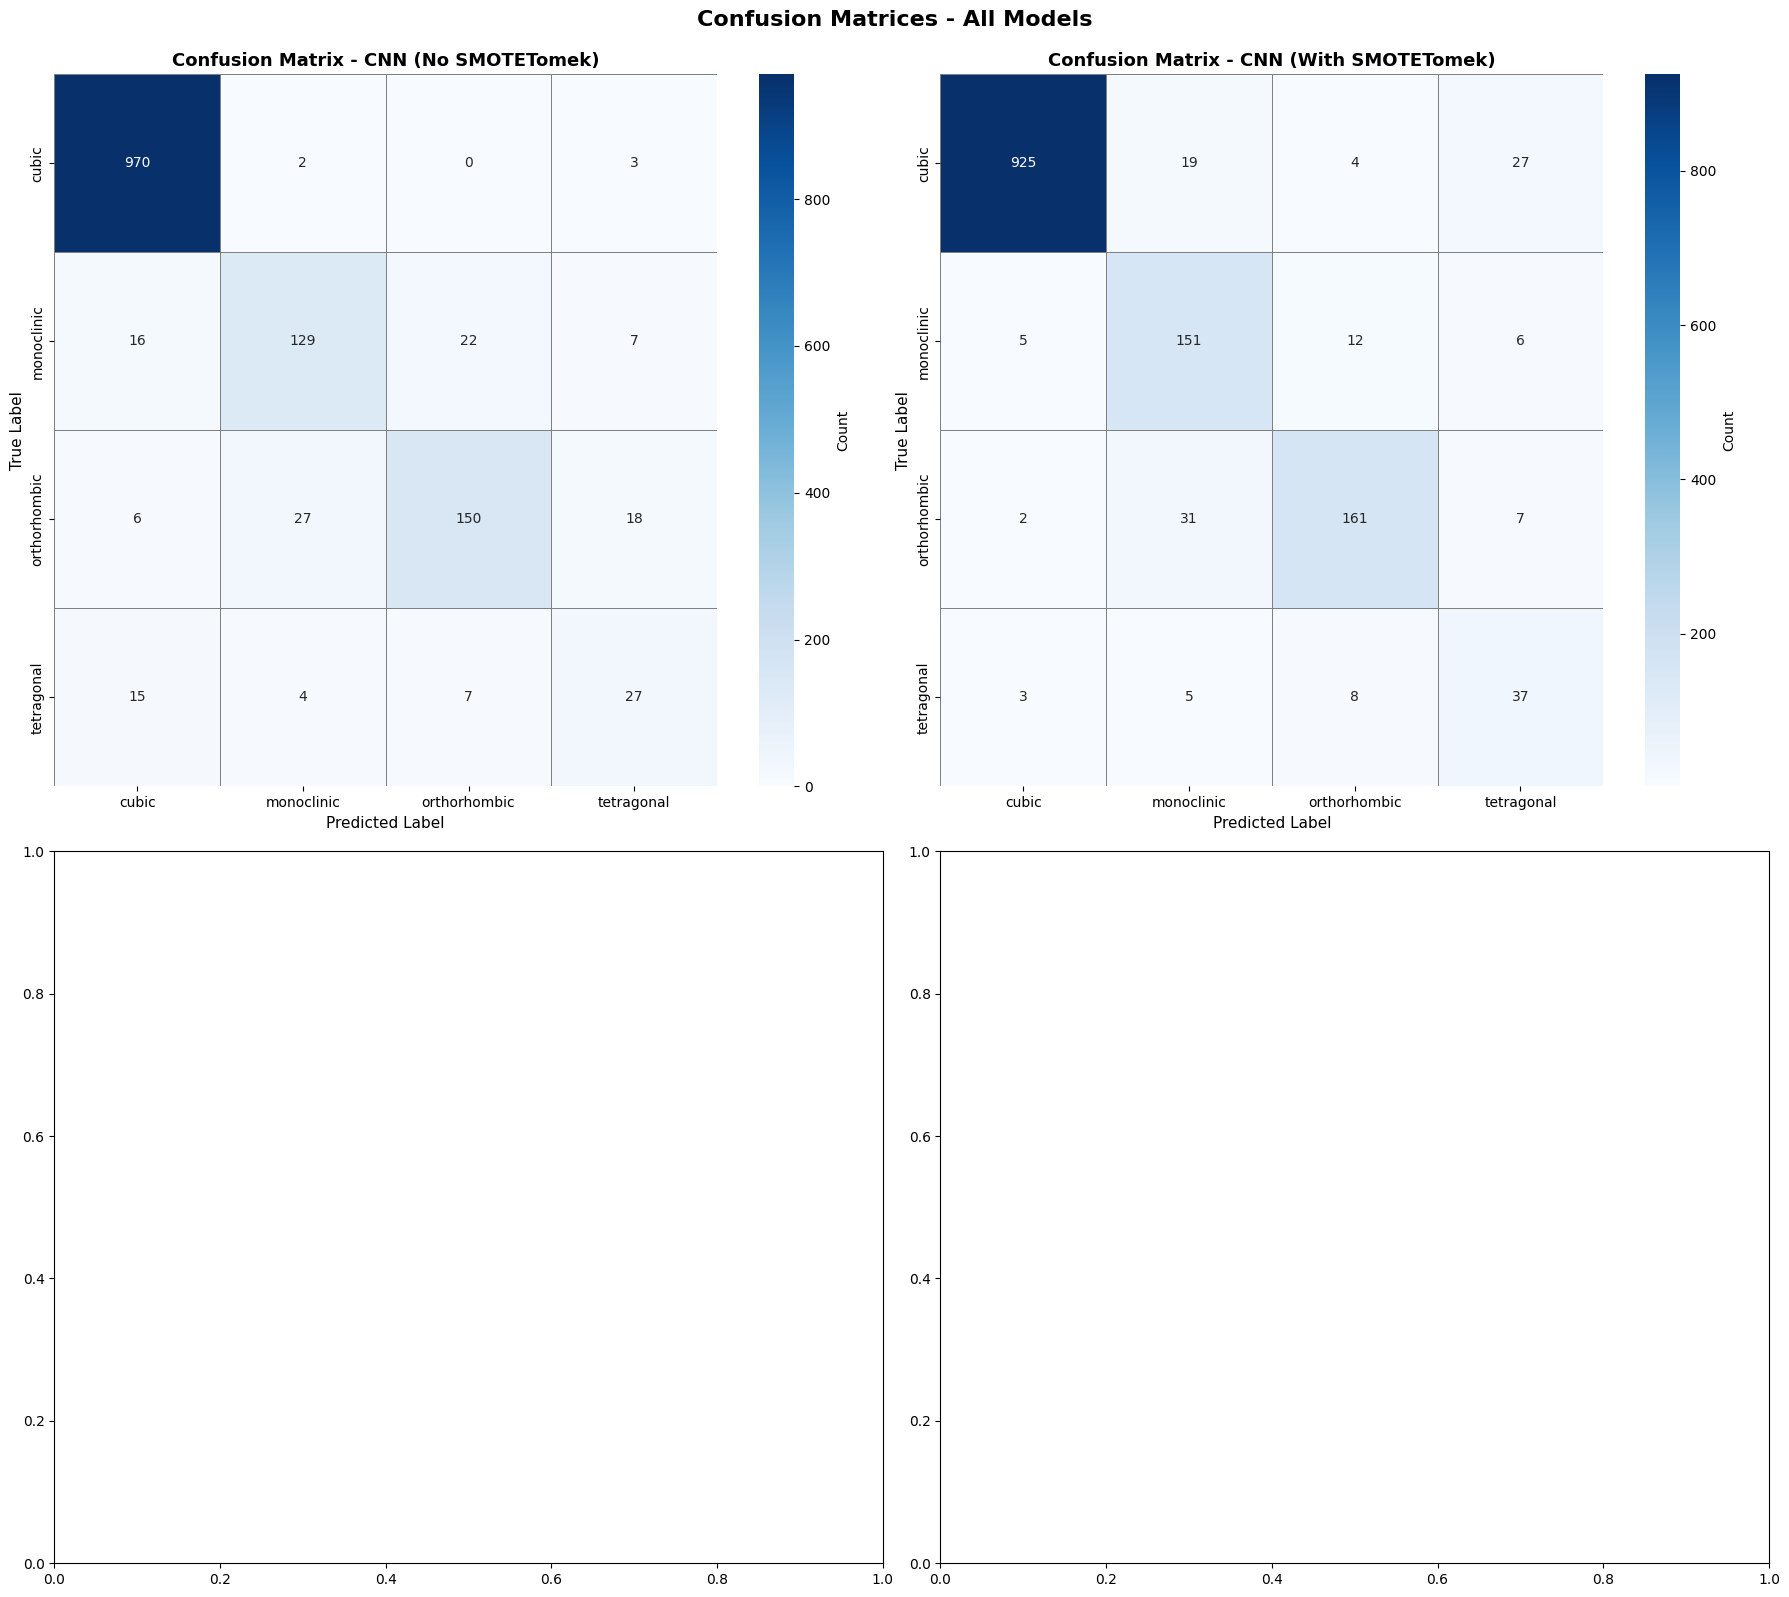

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
                ax=axes[idx])

    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices - All Models', fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# FEATURE EXTRACTION AND t-SNE VISUALIZATION
# ============================================================================

def extract_cnn_features(model, X_data):
    """Extract features from feature layer"""
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feature_layer = model.get_layer("feature_layer")
    feat_model = Model(inputs=model.input, outputs=feature_layer.output)
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("\n" + "="*70)
print("EXTRACTING FEATURES FOR t-SNE VISUALIZATION")
print("="*70)

# Extract features from all models (using test data)
features_cnn_no_smote = extract_cnn_features(model_cnn_no_smote, X_test_raw)
features_cnn_with_smote = extract_cnn_features(model_cnn_with_smote, X_test_raw)


print("✓ Feature extraction complete for all models!")


EXTRACTING FEATURES FOR t-SNE VISUALIZATION
✓ Feature extraction complete for all models!


In [ ]:
# ============================================================================
# t-SNE VISUALIZATION FOR ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING t-SNE VISUALIZATIONS")
print("="*70)

# Apply t-SNE to all feature sets
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=0)

print("Applying t-SNE to CNN (No SMOTETomek) features...")
X_tsne_cnn_no_smote = tsne.fit_transform(features_cnn_no_smote)

print("Applying t-SNE to CNN (With SMOTETomek) features...")
X_tsne_cnn_with_smote = tsne.fit_transform(features_cnn_with_smote)


print("✓ t-SNE transformation complete for all models!")


GENERATING t-SNE VISUALIZATIONS
Applying t-SNE to CNN (No SMOTETomek) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN (With SMOTETomek) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE transformation complete for all models!


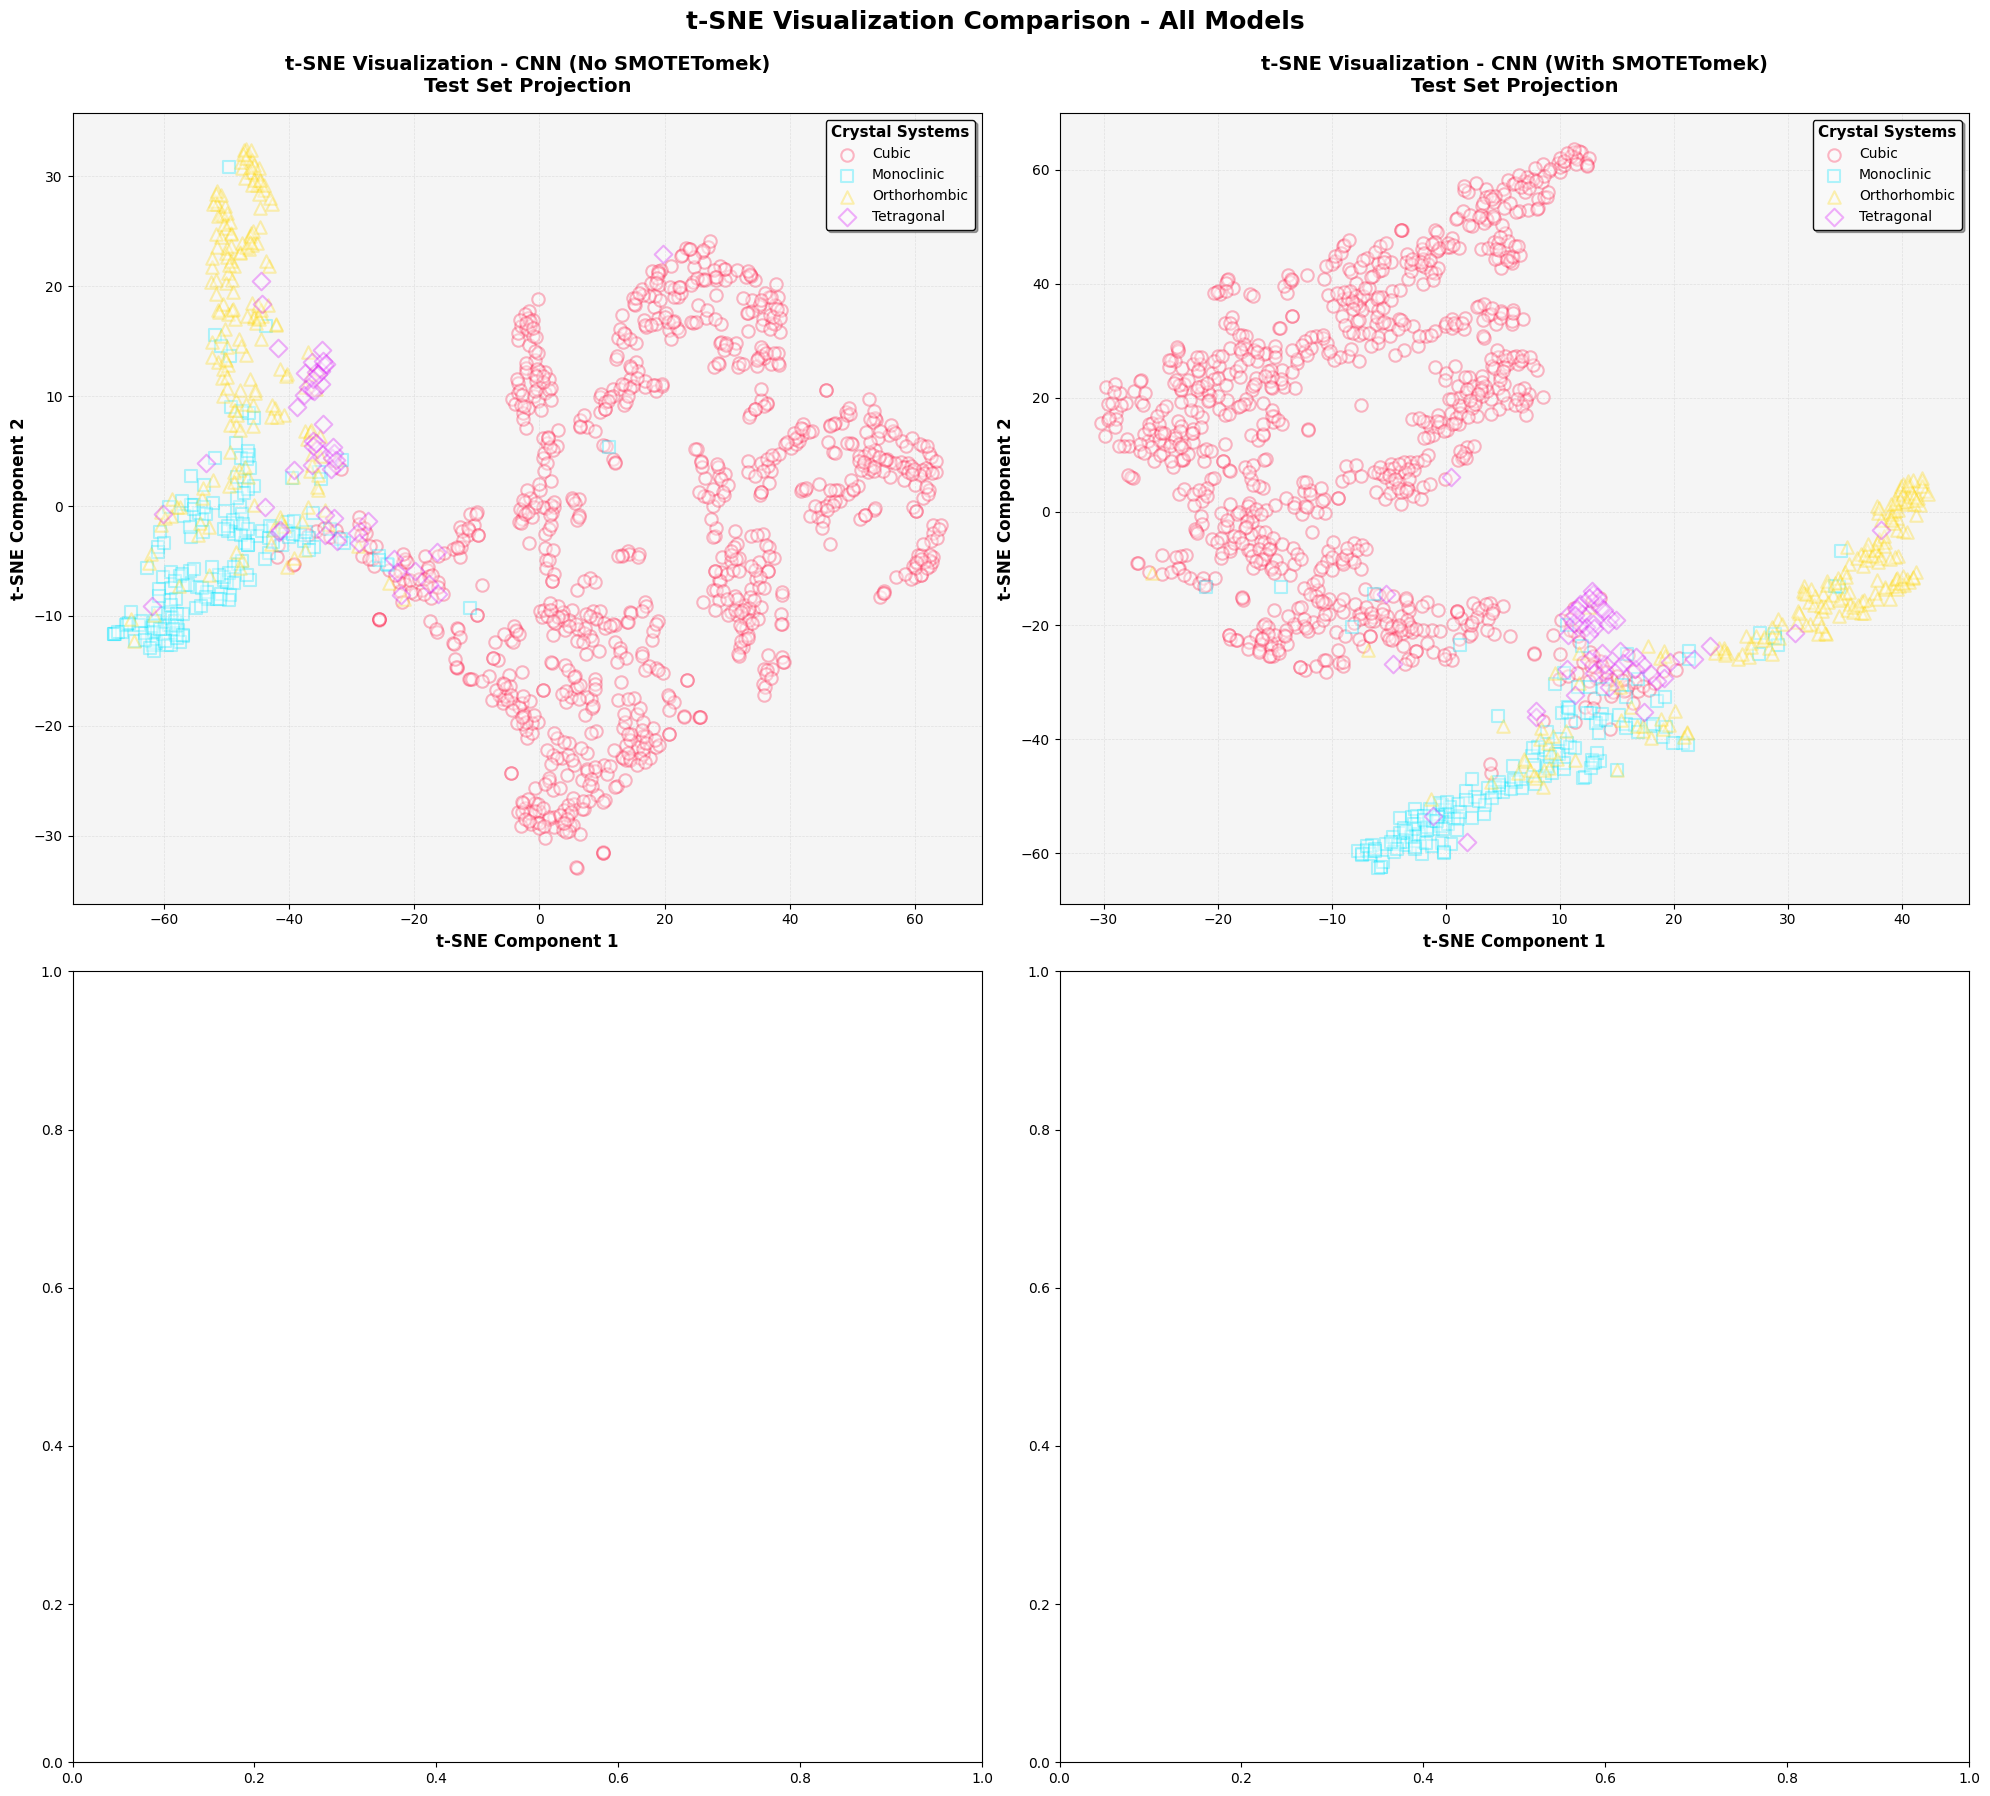


✓ t-SNE visualizations complete!
✓ Visualized 1403 test samples for each model


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.ravel()

# Warna garis tepi per kelas
edge_colors = [
    '#FF1744',  # Merah - Cubic
    '#00E5FF',  # Cyan - Monoclinic
    '#FFD600',  # Kuning - Orthorhombic
    '#D500F9'   # Ungu - Tetragonal
]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

tsne_data = [
    (X_tsne_cnn_no_smote, "CNN (No SMOTETomek)"),
    (X_tsne_cnn_with_smote, "CNN (With SMOTETomek)")
]

for idx, (X_tsne, title) in enumerate(tsne_data):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c='white',
                   label=name.capitalize(),
                   s=80,
                   alpha=0.3,
                   edgecolors=edge_colors[i],  # garis tepi berwarna per kelas
                   linewidths=1.5,
                   marker=markers[i])

    ax.set_title(f't-SNE Visualization - {title}\nTest Set Projection',
                 fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')

    legend = ax.legend(fontsize=10, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 11, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Visualization Comparison - All Models',
            fontweight='bold', fontsize=18, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ t-SNE visualizations complete!")
print(f"✓ Visualized {len(X_test)} test samples for each model")

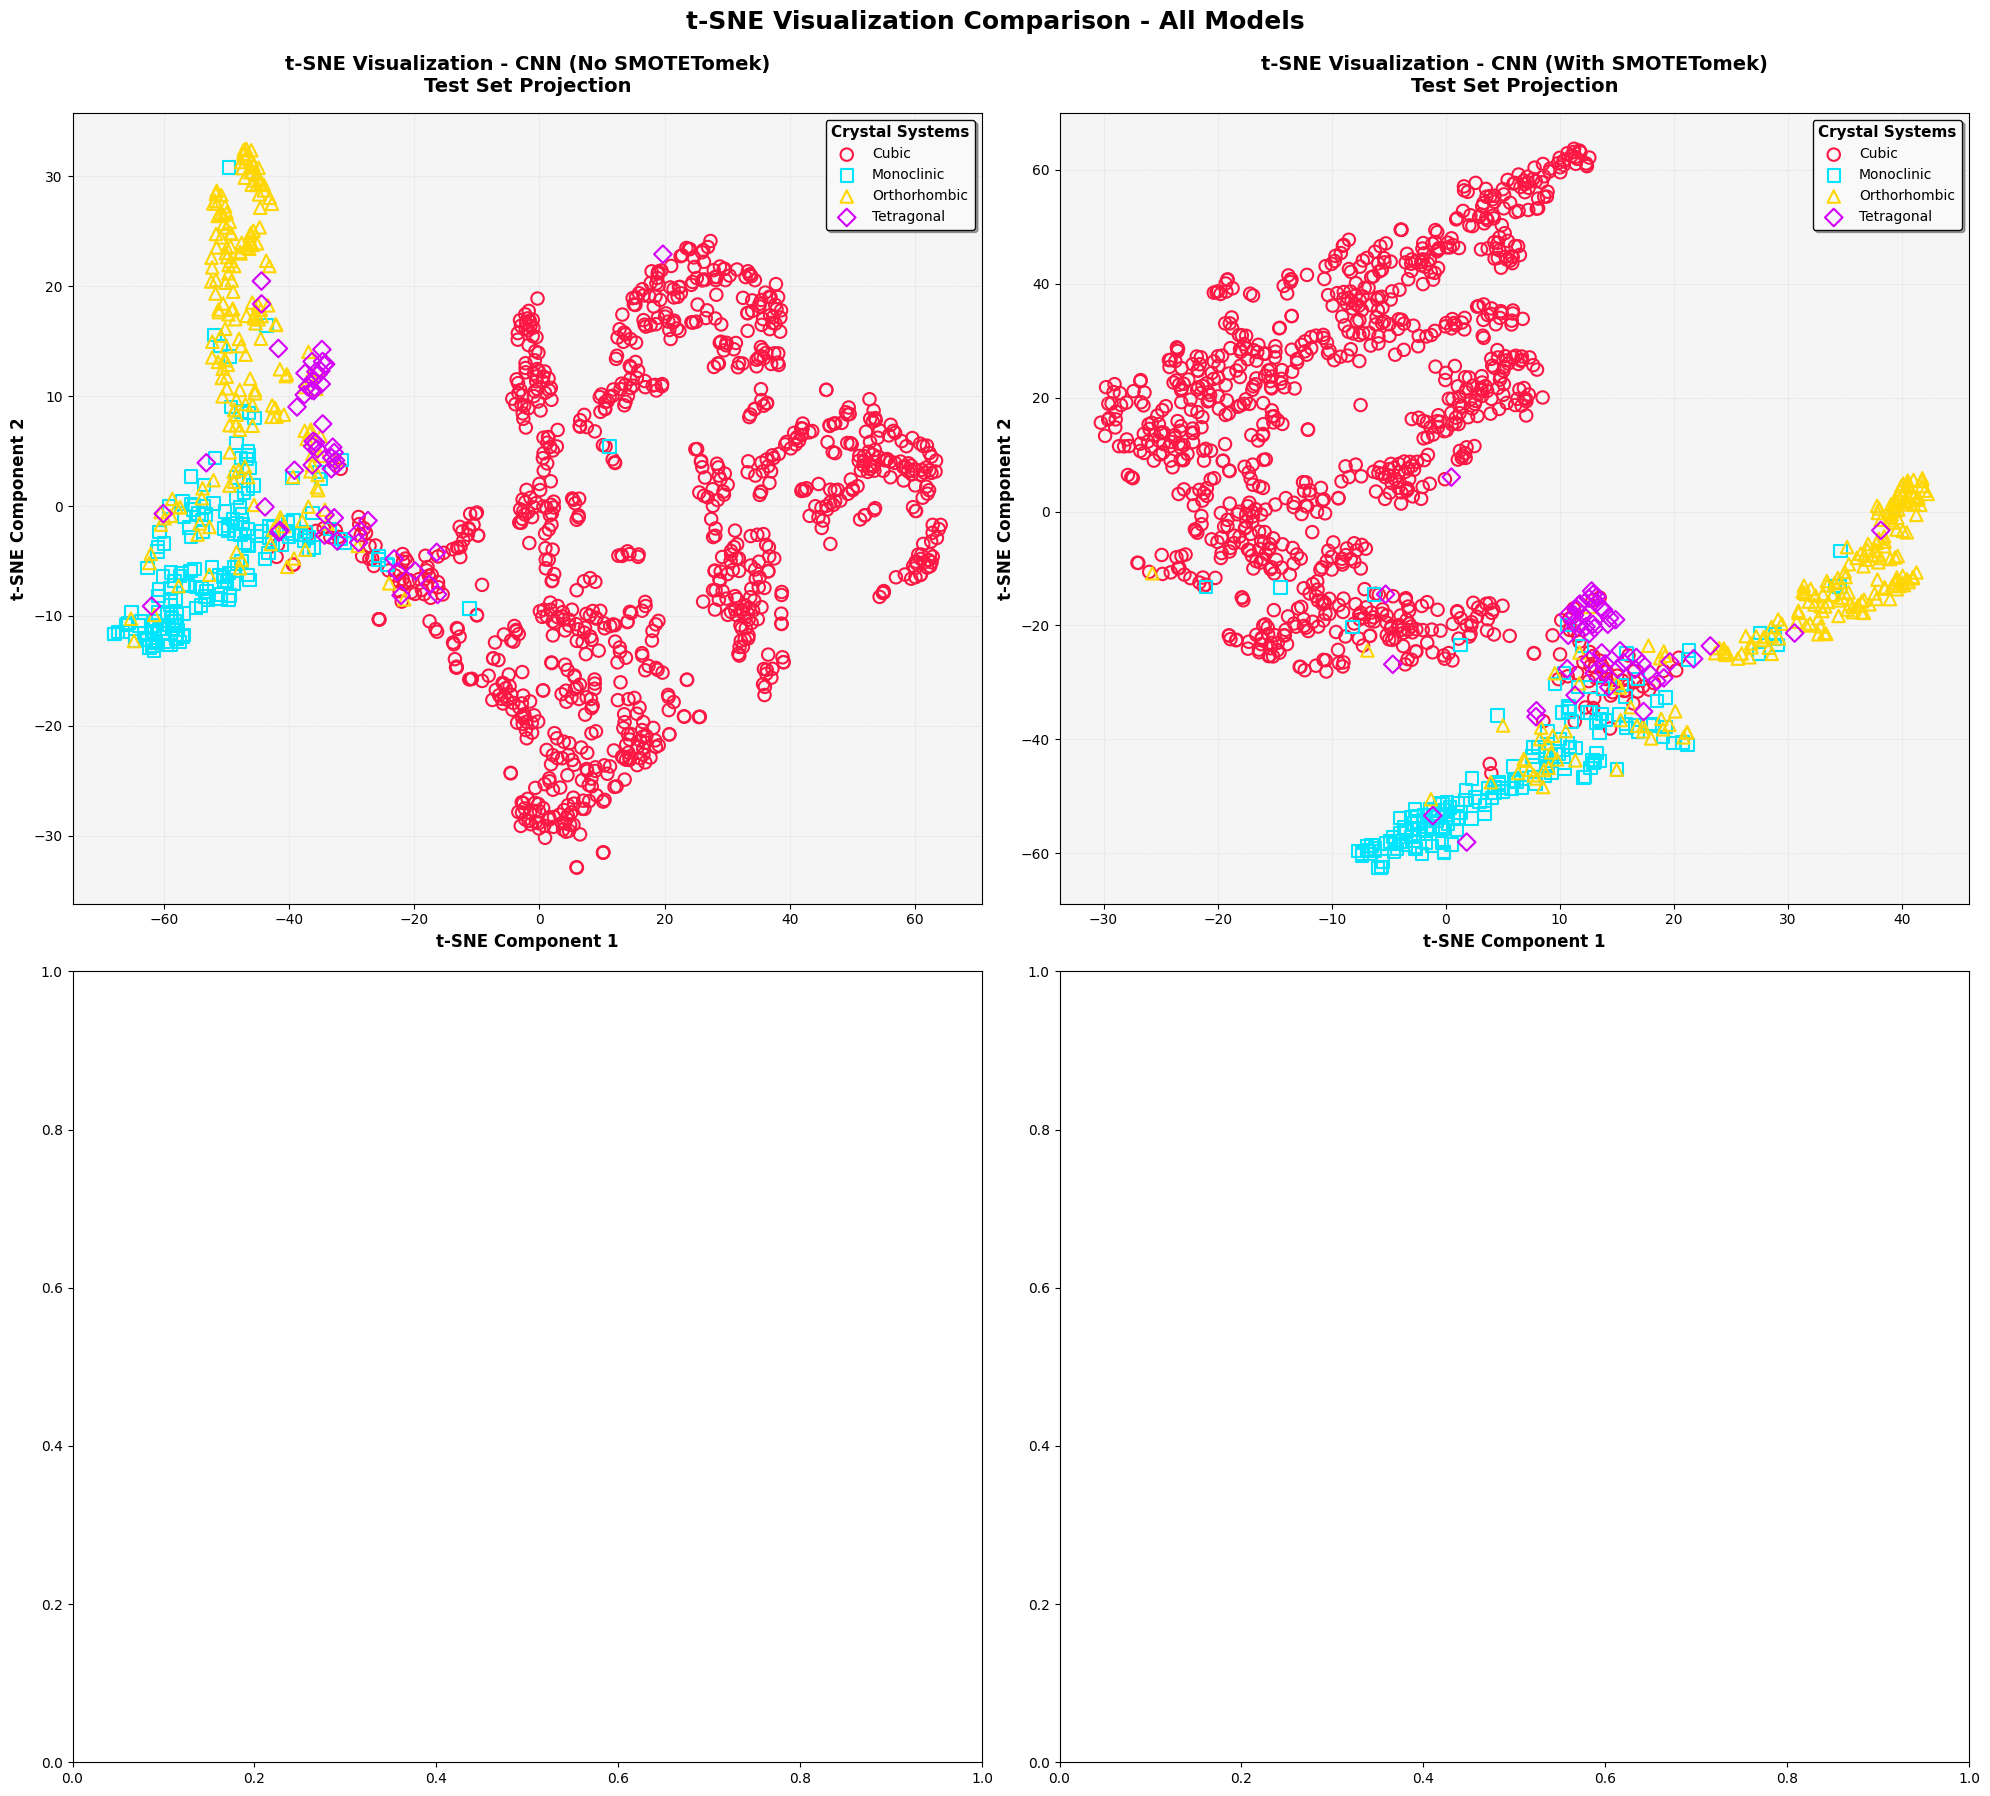


✓ t-SNE visualizations complete!
✓ Visualized 1403 test samples for each model


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.ravel()

# Bright and distinct color palette
colors_bright = [
    '#FF1744',  # Bright Red - Cubic
    '#00E5FF',  # Bright Cyan - Monoclinic
    '#FFD600',  # Bright Yellow - Orthorhombic
    '#D500F9'   # Bright Purple - Tetragonal
]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

tsne_data = [
    (X_tsne_cnn_no_smote, "CNN (No SMOTETomek)"),
    (X_tsne_cnn_with_smote, "CNN (With SMOTETomek)")
]

for idx, (X_tsne, title) in enumerate(tsne_data):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c='none',                  # isi kosong/transparan
                   label=name.capitalize(),
                   s=80,
                   edgecolors=colors_bright[i],  # garis tepi warna-warni
                   linewidths=1.5,
                   marker=markers[i])

    ax.set_title(f't-SNE Visualization - {title}\nTest Set Projection',
                 fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')

    legend = ax.legend(fontsize=10, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 11, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Visualization Comparison - All Models',
            fontweight='bold', fontsize=18, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ t-SNE visualizations complete!")
print(f"✓ Visualized {len(X_test)} test samples for each model")